In [1]:
import os
import sys

os.chdir("..")
sys.path.append(os.getcwd())

from experiment_runner import run_all_experiments
from analysis import *

In [2]:
search_space = {
    "model": ["cnn", "resnet18"],

    "lr": (1e-4, 2e-3, "log"),
    "weight_decay": (3e-5, 5e-4, "log"),

    "dropout": [0.0, 0.3, 0.5],
    "batch_size": [64, 128],
}

In [3]:
run_all_experiments(
    search_space,
    n_samples=20,
    folder="test"
)

Seed: 0, Config: {"lr": 0.0010161083833347877, "weight_decay": 0.00010312508690972956, "dropout": 0.3, "batch_size": 128, "model": "cnn"}
Epoch 1: train=1.7460, val=1.5117, acc=0.5267
Epoch 2: train=1.5317, val=1.4188, acc=0.5709


KeyboardInterrupt: 

In [4]:
df = load_results("./results/exp1_hparams")
df.head()

,lr,weight_decay,dropout,batch_size,augmentation,model,val_acc,test_acc,val_macro_f1,test_macro_f1,val_f1_mean,test_f1_mean
0,0.0001,0.001,0.5,128,True,bigcnn,0.794289,0.793433,0.793615,0.792967,0.793615,0.792967
1,0.0001,0.001,0.5,128,True,bigcnn,0.795822,0.793011,0.795398,0.792739,0.795398,0.792739
2,0.0001,0.001,0.5,128,True,bigcnn,0.796578,0.793300,0.796527,0.793269,0.796527,0.793269


In [5]:
summary = summarize(df, ["model", "lr", "weight_decay", "dropout", "batch_size", "augmentation"])
summary.head(10)

,model,lr,weight_decay,dropout,batch_size,augmentation,mean_acc,std_acc,mean_f1,std_f1,mean_val_acc,mean_val_f1
0,bigcnn,0.0001,0.001,0.5,128,True,0.793248,0.000216,0.792991,0.000266,0.795563,0.79518


In [6]:
best = get_best_configs(df, top_k=5)
best

,lr,weight_decay,dropout,batch_size,augmentation,model,val_acc,test_acc,val_macro_f1,test_macro_f1,val_f1_mean,test_f1_mean
0,0.0001,0.001,0.5,128,True,bigcnn,0.794289,0.793433,0.793615,0.792967,0.793615,0.792967
2,0.0001,0.001,0.5,128,True,bigcnn,0.796578,0.793300,0.796527,0.793269,0.796527,0.793269
1,0.0001,0.001,0.5,128,True,bigcnn,0.795822,0.793011,0.795398,0.792739,0.795398,0.792739


<Figure size 640x480 with 0 Axes>

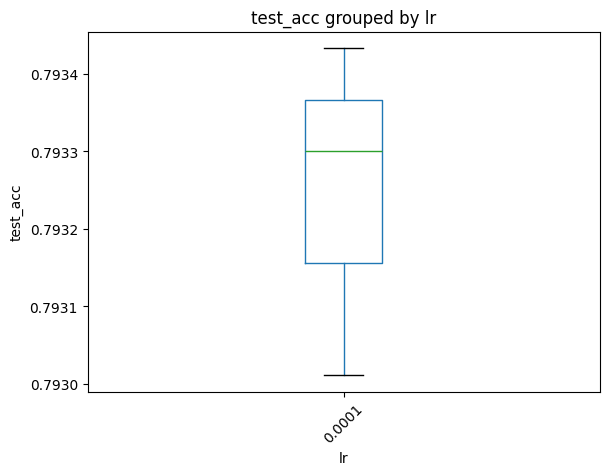

<Figure size 640x480 with 0 Axes>

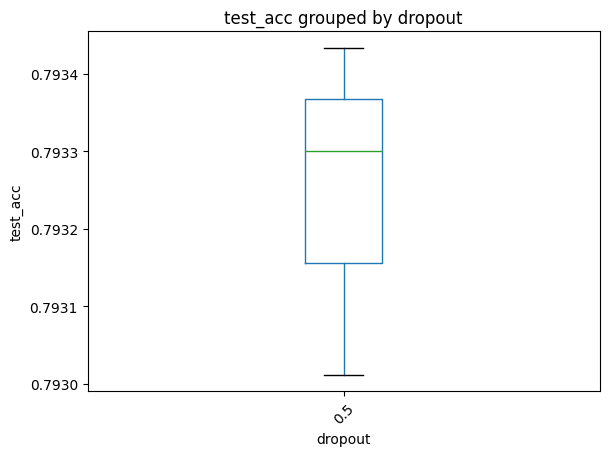

<Figure size 640x480 with 0 Axes>

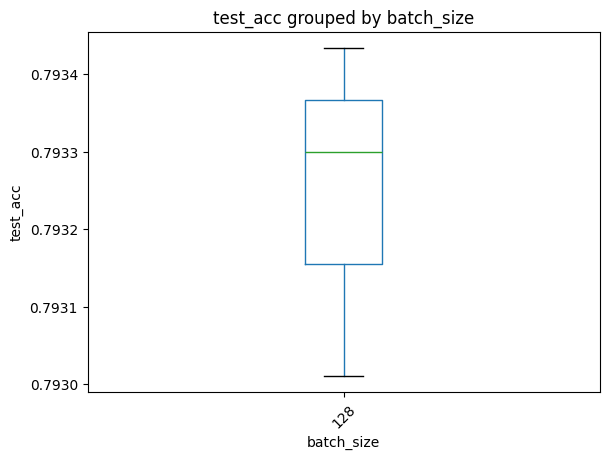

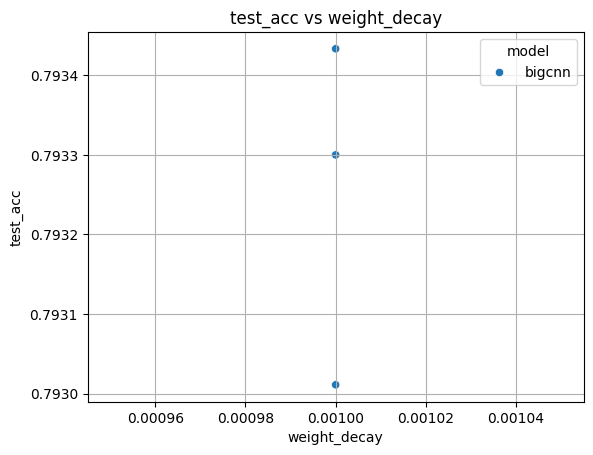

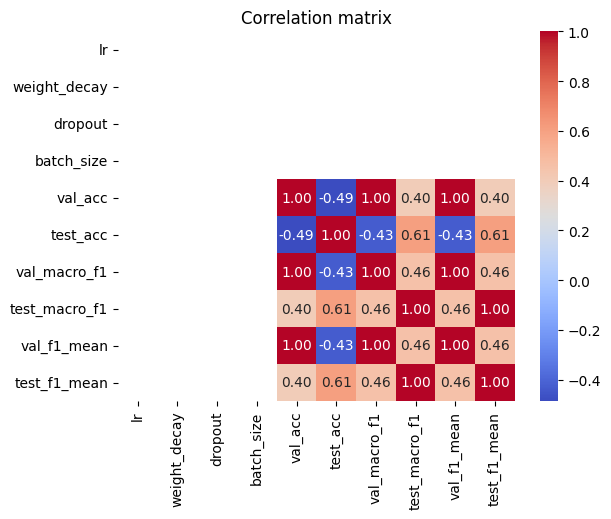

In [7]:
boxplot_metric(df, x="lr")
boxplot_metric(df, x="dropout")
boxplot_metric(df, x="batch_size")

scatter_plot(df, x="weight_decay")
correlation_plot(df)